In [37]:
using POMDPModels: SimpleGridWorld
using LinearAlgebra: I
using CommonRLInterface: render, actions, act!, observe, reset!, AbstractEnv, observations, terminated, clone
import POMDPTools
using SparseArrays
using Statistics: mean

# SARSA

In [38]:
function sarsa_episode!(Q, env; ϵ=0.10, γ=0.99, α=0.2)
    start = time()
    
    function policy(s)
        if rand() < ϵ
            return rand(actions(env))
        else
            return argmax(a->Q[(s, a)], actions(env))
        end
    end

    s = observe(env)
    a = policy(s)
    r = act!(env, a)
    sp = observe(env)
    hist = [s]

    while !terminated(env)
        ap = policy(sp)

        Q[(s,a)] += α*(r + γ*Q[(sp, ap)] - Q[(s, a)])

        s = sp
        a = ap
        r = act!(env, a)
        sp = observe(env)
        push!(hist, sp)
    end

    Q[(s,a)] += α*(r - Q[(s, a)])

    return (hist=hist, Q = copy(Q), time=time()-start)
end

sarsa_episode! (generic function with 1 method)

In [ ]:
function sarsa!(env; n_episodes=1000)
    Q = Dict((s, a) => 0.0 for s in observations(env), a in actions(env))
    episodes = []
    
    for i in 1:n_episodes
        reset!(env)
        push!(episodes, sarsa_episode!(Q, env;
                                       ϵ=max(0.1, 1-i/n_episodes)))
    end
    
    return episodes
end

sarsa! (generic function with 1 method)

In [40]:
m = SimpleGridWorld()
env = convert(AbstractEnv, m)

POMDPTools.CommonRLIntegration.MDPCommonRLEnv{AbstractArray, SimpleGridWorld, StaticArraysCore.SVector{2, Int64}}(SimpleGridWorld((10, 10), Dict{StaticArraysCore.SVector{2, Int64}, Float64}([4, 6] => -5.0, [9, 3] => 10.0, [4, 3] => -10.0, [8, 8] => 3.0), Set(StaticArraysCore.SVector{2, Int64}[[4, 6], [9, 3], [4, 3], [8, 8]]), 0.7, 0.95), [3, 3])

In [41]:
sarsa_episodes = sarsa!(env, n_episodes=10_000);

In [42]:
# using Interact
# @manipulate for episode in 1:length(sarsa_episodes), step in 1:maximum(ep->length(ep.hist), sarsa_episodes)
#     ep = sarsa_episodes[episode]
#     i = min(step, length(ep.hist))
#     POMDPTools.render(m, (s=ep.hist[i],), color=s->maximum(map(a->ep.Q[(s,a)], actions(env))))
# end

# SARSA-λ

In [43]:
function sarsa_lambda_episode!(Q, env; ϵ=0.10, γ=0.99, α=0.05, λ=0.9)

    start = time()
    
    function policy(s)
        if rand() < ϵ
            return rand(actions(env))
        else
            return argmax(a->Q[(s, a)], actions(env))
        end
    end

    s = observe(env)
    a = policy(s)
    r = act!(env, a)
    sp = observe(env)
    hist = [s]
    N = Dict((s, a) => 0.0)

    while !terminated(env)
        ap = policy(sp)

        N[(s, a)] = get(N, (s, a), 0.0) + 1

        δ = r + γ*Q[(sp, ap)] - Q[(s, a)]

        for ((s, a), n) in N
            Q[(s, a)] += α*δ*n
            N[(s, a)] *= γ*λ
        end

        s = sp
        a = ap
        r = act!(env, a)
        sp = observe(env)
        push!(hist, sp)
    end

    N[(s, a)] = get(N, (s, a), 0.0) + 1
    δ = r - Q[(s, a)]

    for ((s, a), n) in N
        Q[(s, a)] += α*δ*n
        N[(s, a)] *= γ*λ
    end

    return (hist=hist, Q = copy(Q), time=time()-start)
end

sarsa_lambda_episode! (generic function with 1 method)

In [44]:
function sarsa_lambda!(env; n_episodes=100, kwargs...)
    Q = Dict((s, a) => 0.0 for s in observations(env), a in actions(env))
    episodes = []
    
    for i in 1:n_episodes
        reset!(env)
        push!(episodes, sarsa_lambda_episode!(Q, env;
                                              ϵ=max(0.01, 1-i/n_episodes),
                                              kwargs...))
    end
    
    return episodes
end

sarsa_lambda! (generic function with 1 method)

In [45]:
lambda_episodes = sarsa_lambda!(env, n_episodes=10000, α=0.1, λ=0.3);

In [46]:
# using Interact
# @manipulate for episode in 1:length(lambda_episodes), step in 1:maximum(ep->length(ep.hist), lambda_episodes)
#     ep = lambda_episodes[episode]
#     i = min(step, length(ep.hist))
#     POMDPTools.render(m, (s=ep.hist[i],), color=s->maximum(map(a->ep.Q[(s,a)], actions(env))))
# end

### Q-learning

In [47]:
function Q_learning_episode!(Q, env; γ=0.99, α=0.2, ϵ=0.10)
    start = time()
    
    # Epsilon-Greedy Policy
    # a <- argmax Q(s,a) w.p/ 1-ϵ, Rand(A) w.p. ϵ
    function ϵ_greedy_policy(s)
        if rand() < ϵ
            return rand(actions(env))
        else
            return argmax(a->Q[(s, a)], actions(env))
        end
    end
    
    # First Step
    s = observe(env)    # initial state
    a = ϵ_greedy_policy(s)  # initial action
    r = act!(env, a)    
    sp = observe(env)
    hist = [s]
    
    # All other steps Steps
    while !terminated(env)
    
        # a ← argmax Q(s,a) w.p/ 1-ϵ, Rand(A) w.p. ϵ
        a = ϵ_greedy_policy(s)

        # r ← act!(env, a)
        r = act!(env, a)

        # s' ← observe(env)
        sp = observe(env)

        # Q(s,a) <- Q(s,a) + α*(r + γ*max_a' Q(s',a') - Q(s,a))
        Q[(s,a)] += α*(r + γ*maximum([Q[(sp,ap)] for ap in actions(env)]) - Q[(s,a)])
        
        # s ← s'
        s = sp
        push!(hist, sp)
    end

    # Value for terminal state
    Q[(s,a)] += α*(r - Q[(s, a)])

    return (hist=hist, Q = copy(Q), time=time()-start)
end

Q_learning_episode! (generic function with 1 method)

In [48]:
function Q_learning!(env; n_episodes=10000, kwargs...)
    # Q(s,a) <- 0 ∀ s,a
    Q = Dict((s, a) => 0.0 for s in observations(env), a in actions(env))
    episodes = []
    
    for i in 1:n_episodes
        # println("episode: $(i)")
        reset!(env)
        push!(episodes, Q_learning_episode!(Q, env; kwargs...))
    end
    
    return episodes
end

Q_learning! (generic function with 1 method)

In [49]:
Q_episodes = Q_learning!(env, n_episodes=10000, γ=0.99, α=0.2)

10000-element Vector{Any}:
 (hist = StaticArraysCore.SVector{2, Int64}[[7, 10], [7, 9], [7, 10], [7, 10], [8, 10], [8, 10], [8, 10], [8, 10], [8, 10], [8, 10]  …  [8, 10], [8, 10], [8, 10], [8, 10], [8, 10], [8, 9], [8, 10], [8, 9], [8, 8], [-1, -1]], Q = Dict{Tuple{StaticArraysCore.SVector{2, Int64}, Symbol}, Float64}(([1, 4], :up) => 0.0, ([5, 8], :up) => 0.0, ([9, 2], :left) => 0.0, ([10, 3], :down) => 0.0, ([9, 10], :left) => 0.0, ([2, 3], :down) => 0.0, ([10, 6], :left) => 0.0, ([3, 1], :right) => 0.0, ([2, 6], :left) => 0.0, ([7, 7], :right) => 0.0…), time = 0.0)
 (hist = StaticArraysCore.SVector{2, Int64}[[5, 6], [5, 8], [5, 9], [5, 10], [5, 9], [5, 10], [6, 10], [6, 10], [6, 10], [6, 10]  …  [5, 10], [6, 10], [5, 10], [5, 10], [5, 9], [6, 9], [6, 8], [7, 8], [8, 8], [-1, -1]], Q = Dict{Tuple{StaticArraysCore.SVector{2, Int64}, Symbol}, Float64}(([1, 4], :up) => 0.0, ([5, 8], :up) => 0.0, ([9, 2], :left) => 0.0, ([10, 3], :down) => 0.0, ([9, 10], :left) => 0.0, ([2, 3], :down) =

# Learning curves

In [50]:
using Plots

In [ ]:
function evaluate(env, policy, n_episodes=10000, max_steps=10000, γ=1.0)
    returns = Float64[]
    for _ in 1:n_episodes
        t = 0
        r = 0.0
        reset!(env)
        s = observe(env)
        while !terminated(env)
            a = policy(s)
            r += γ^t*act!(env, a)
            s = observe(env)
            t += 1
        end
        push!(returns, r)
    end
    return returns
end

evaluate (generic function with 4 methods)

In [52]:
episodes = Dict("SARSA"=>sarsa_episodes, "SARSA-λ"=>lambda_episodes, "Q-learning"=>Q_episodes)

Dict{String, Vector{Any}} with 3 entries:
  "SARSA-λ"    => [(hist = SVector{2, Int64}[[9, 8], [9, 6], [8, 6], [7, 6], [6…
  "Q-learning" => [(hist = SVector{2, Int64}[[7, 10], [7, 9], [7, 10], [7, 10],…
  "SARSA"      => [(hist = SVector{2, Int64}[[3, 1], [1, 1], [1, 1], [1, 1], [1…

## By # Steps

x = total number of steps in env

y = average return

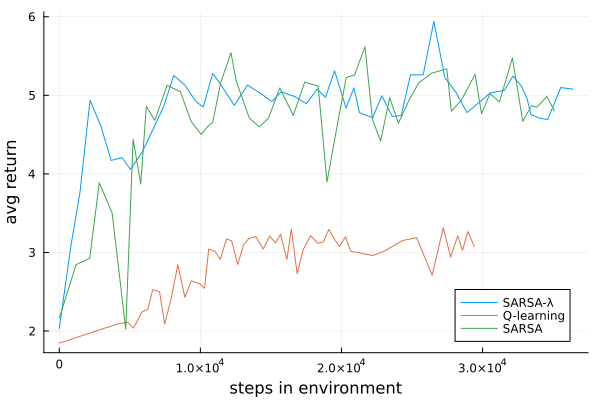

In [53]:
p = plot(xlabel="steps in environment", ylabel="avg return")
n = 20
stop = 1000
for (name, eps) in episodes
    Q = Dict((s, a) => 0.0 for s in observations(env), a in actions(env))
    xs = [0]
    ys = [mean(evaluate(env, s->argmax(a->Q[(s, a)], actions(env))))]
    for i in n:n:min(stop, length(eps))
        newsteps = sum(length(ep.hist) for ep in eps[i-n+1:i])
        push!(xs, last(xs) + newsteps)
        Q = eps[i].Q
        push!(ys, mean(evaluate(env, s->argmax(a->Q[(s, a)], actions(env)))))
    end    
    plot!(p, xs, ys, label=name)
end
p

## By wall clock time

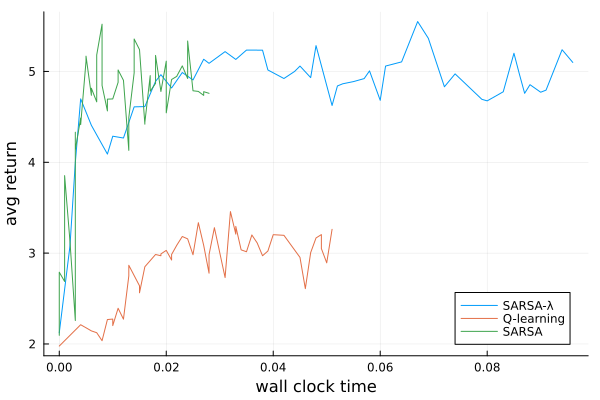

In [54]:
p = plot(xlabel="wall clock time", ylabel="avg return")
n = 20 
stop = 1000
for (name,eps) in episodes
    Q = Dict((s, a) => 0.0 for s in observations(env), a in actions(env))
    xs = [0.0]
    ys = [mean(evaluate(env, s->argmax(a->Q[(s, a)], actions(env))))]
    for i in n:n:min(stop, length(eps))
        newtime = sum(ep.time for ep in eps[i-n+1:i])
        push!(xs, last(xs) + newtime)
        Q = eps[i].Q
        push!(ys, mean(evaluate(env, s->argmax(a->Q[(s, a)], actions(env)))))
    end    
    plot!(p, xs, ys, label=name)
end
p